In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 90

## 1. A dataset that is NOT linearly separable

make_moons is a classic synthetic dataset: two classes that draw interlocking half-moons. *No straight line* can separate them correctly. No matter how we tune the weights, a linear boundary will misclassify points along the curve.

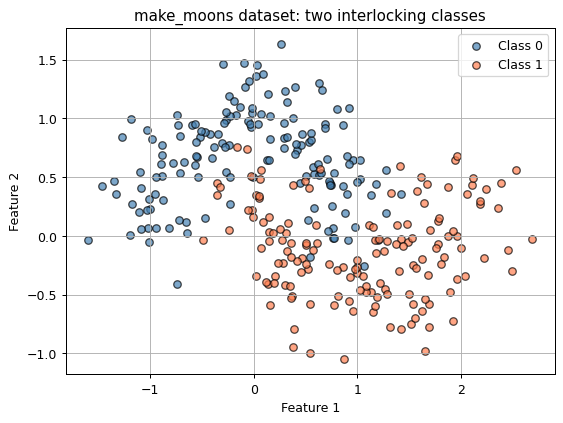

In [7]:
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', label='Class 0', alpha=0.7, edgecolor='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', label='Class 1', alpha=0.7, edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('make_moons dataset: two interlocking classes')
plt.legend()
plt.grid(alpha=0.9)
plt.show()

Accuracy EXCLUSIVO con Regresión Logística (test): 91.67%


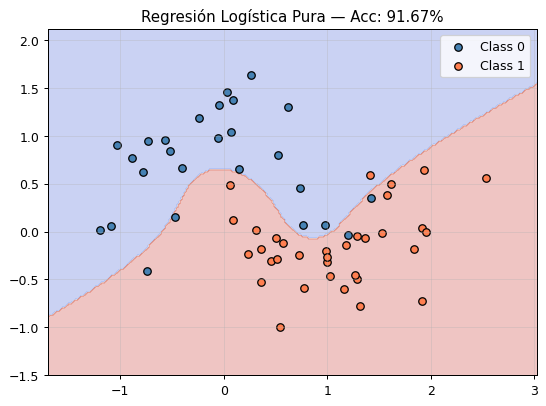

In [15]:
def plot_decision_boundary(model, X, y, title):
    """Visualize the model's decision boundary on the 2D plane."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', edgecolor='k', label='Class 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', edgecolor='k', label='Class 1')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


advanced_logreg = Pipeline([
    ("poly_features", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
    # Aumentamos C=100 para forzar a la regresión logística a ajustarse mejor a la curva
    ("clf", LogisticRegression(C=100, random_state=42, max_iter=1000)) 
])

advanced_logreg.fit(X_train, y_train)

acc_advanced = accuracy_score(y_test, advanced_logreg.predict(X_test))

print(f'Accuracy EXCLUSIVO con Regresión Logística (test): {acc_advanced:.2%}')

plot_decision_boundary(advanced_logreg, X_test, y_test, f'Regresión Logística Pura — Acc: {acc_advanced:.2%}')

## 3. Attempt 2: decision tree

A tree works in a radically different way. Instead of learning weights, it **learns questions**:

```
Is Feature 2 > 0.3?
├── Yes → Is Feature 1 > 0.5?
│   ├── Yes → Class 1
│   └── No  → Class 0
└── No  → Is Feature 1 > -0.2?
    ├── Yes → Class 0
    └── No  → Class 1
```

Each question splits the space with a **line parallel to one axis**. The combination of several questions produces a staircase-shaped boundary that can approximate any shape.

Decision tree accuracy (max_depth=5, test): 0.900
Improvement over logistic regression: +1.7 points


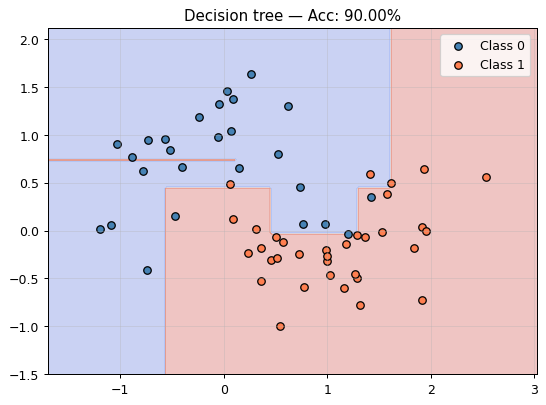

In [17]:
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
acc_tree = accuracy_score(y_test, tree.predict(X_test))

print(f'Decision tree accuracy (max_depth=5, test): {acc_tree:.3f}')
print(f'Improvement over logistic regression: +{(acc_tree - acc_logreg)*100:.1f} points')

plot_decision_boundary(tree, X_test, y_test, f'Decision tree — Acc: {acc_tree:.2%}')

--- Resultados de Optimización ---
Mejores hiperparámetros: {'max_depth': 6, 'max_leaf_nodes': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Decision tree accuracy (Test Óptimo): 0.850


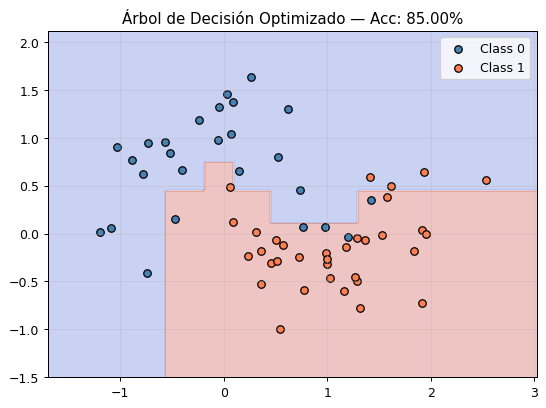

In [20]:
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, None],    
    'min_samples_split': [2, 5, 10, 15],      
    'min_samples_leaf': [1, 2, 4, 6, 8],      
    'max_leaf_nodes': [None, 10, 15, 20, 25]  
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1 
)

grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_

acc_best_tree = accuracy_score(y_test, best_tree.predict(X_test))

print("--- Resultados de Optimización ---")
print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Decision tree accuracy (Test Óptimo): {acc_best_tree:.3f}")

plot_decision_boundary(best_tree, X_test, y_test, f'Árbol de Decisión Optimizado — Acc: {acc_best_tree:.2%}')

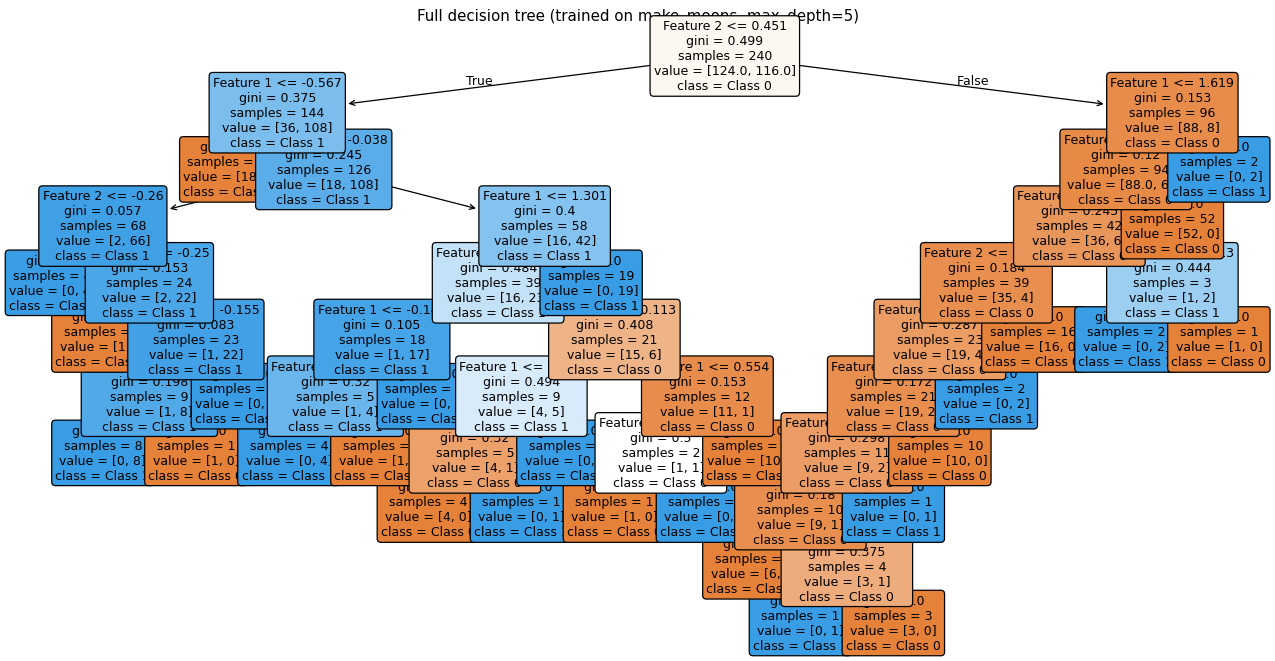

In [24]:
plt.figure(figsize=(18, 9))
plot_tree(
    tree,
    filled=True,
    rounded=True,
    feature_names=['Feature 1', 'Feature 2'],
    class_names=['Class 0', 'Class 1'],
    fontsize=10
)
plt.title('Full decision tree (trained on make_moons, max_depth=5)')
plt.show()

#Explicación

It's a decision tree, usually with yes/no answers. The Gini coefficient helps us decide the best way to divide the data to create accurate prediction rules. A sample is more like an individual record or unit of data used to train or evaluate a model.



# CLASE 11/06/2026

### Example 1

